# 실습 15: 언제부터 그랬는지 보기
- 상황: 이상한 줄은 찾았는데 그게 언제 나온 건지 모른다
- 목표: 시각을 되살려 흐름으로 감시하고, 조기 경보 목록으로 마감한다

## Step 0. 앞 실습까지 재현하기

In [1]:
import pandas as pd
from sklearn.ensemble import IsolationForest

df = pd.read_csv("../../day02/lab06_clean-dataset/results/secom_clean.csv")

# 센서 열만 골라 빈칸을 그 열의 중앙값으로 채운다
센서열 = [c for c in df.columns if c.startswith("sensor_")]
df[센서열] = df[센서열].fillna(df[센서열].median())

X = df[센서열]

# 정답은 넣지 않는다 - 센서 값만 담긴 X로 지목한다
탐지기 = IsolationForest(contamination=0.05, random_state=42)
지목 = 탐지기.fit_predict(X)

df["불량여부"] = (df["result"] == "불량").astype(int)
df["이상탐지"] = (지목 == -1)

print("전체 행 수:", len(df))
print("이상탐지 건수:", int(df["이상탐지"].sum()))
print("그중 불량 건수:", int((df["이상탐지"] & (df["불량여부"] == 1)).sum()))

전체 행 수: 1567
이상탐지 건수: 79
그중 불량 건수: 12


---
## Step 1. 오늘 쓸 말 정리하기

### 용어 풀이 - 흐름으로 보는 말

| 수업에서 쓰는 말 | 정식 이름 | 뜻 |
|---|---|---|
| 시계열 | time series | 시간 순서가 있는 기록. 앞뒤가 이어져 있어서 순서를 바꾸면 뜻이 달라진다 |
| 이동평균 | 이동평균 (moving average) | 최근 몇 개의 평균. 들쭉날쭉한 걸 눌러서 흐름만 남긴다 |
| 관리도 | 관리도 (control chart) | 평소 범위를 선으로 그려두고 넘는 순간을 잡는 그림 |
| 관리 한계선 | 관리상한 UCL / 관리하한 LCL | 그 선. 흔히 평균에서 표준편차의 세 배만큼 위아래로 긋는다 |
| 이탈 | 관리 이탈 (out of control) | 관리 한계선을 넘은 것 |
| 관리도로 공정을 지켜보는 일 | 통계적 공정관리 (SPC) | 현장에서 백 년 가까이 써온 방법. 면접에서 이 이름으로 묻는다 |

---
## Step 2. 떨어져 나간 시각 다시 붙이기

In [2]:
import pandas as pd

# ① 파일을 불러오는 것 - 첫날부터 계속 쓴 것
원본 = pd.read_csv("../../data/04_secom.csv")

# ② 글자로 된 시각을 날짜로 바꿔주는 것
# ③ 표기가 섞여 있어도 알아서 읽으라는 뜻. 안 넣으면 오류가 난다. 24/03/03 or 24-03-03 등 형식 다양함
df["측정시각"] = pd.to_datetime(원본["measured_at"], format="mixed")

# 붙이기 전에 확인 - 두 파일의 행 순서가 같아야 붙일 수 있다
# ④ 전부 참일 때만 참이 되는 것
print("정제본 행 수:", len(df), "/ 원본 행 수:", len(원본))
print("답이 전부 같은가:", (df["result"].values == 원본["result"].values).all())

# ⑤ 그 열 기준으로 줄을 세우는 것. sort_values()를 사용하면 새로운 index를 생성해 정렬해야함. 아니면 원본 옆에 새로 정렬된 열이 같이 적혀져있음
# ⑥ 옛 번호를 버리라는 뜻
df = df.sort_values("측정시각").reset_index(drop=True)

print("기간:", df["측정시각"].min(), "~", df["측정시각"].max())

정제본 행 수: 1567 / 원본 행 수: 1567
답이 전부 같은가: True
기간: 2008-01-08 02:02:00 ~ 2008-12-10 18:47:00


### 문법 노트 - 시각 붙이고 줄 세우기

| 밑줄 | 넣은 것 | 하는 일 | 새로 배운 것인가 |
|---|---|---|---|
| ① | `read_csv` | 파일을 불러온다 | 첫날부터 계속 쓴 것 |
| ② | `to_datetime` | 글자로 된 시각을 날짜로 바꾼다 | 정제할 때 한 번 나왔다 |
| ③ | `format="mixed"` | 표기가 섞여 있어도 알아서 읽으라는 뜻 | 새로 배움 · 안 넣으면 오류 |
| ④ | `.all()` | 전부 참일 때만 참 | 새로 배움 |
| ⑤ | `sort_values` | 그 열 기준으로 줄을 세운다 | 새로 배움 |
| ⑥ | `drop` | 번호를 다시 매기고 옛 번호는 버린다 | 새로 배움 |

---
## Step 4. 월별로 보면

In [3]:
# 연-월 단위로 묶을 기준 열을 만든다
df["측정월"] = df["측정시각"].dt.to_period("M").astype(str)

월별 = df.groupby("측정월").agg(
    전체건수=("불량여부", "size"),
    불량건수=("불량여부", "sum"),
)
월별["불량률(%)"] = (월별["불량건수"] / 월별["전체건수"] * 100).round(2)

display(월별)

최고월 = 월별["불량률(%)"].idxmax()
최저월 = 월별["불량률(%)"].idxmin()

print(f"불량률이 가장 높은 달: {최고월} ({월별.loc[최고월, '불량률(%)']}%) / 가장 낮은 달: {최저월} ({월별.loc[최저월, '불량률(%)']}%)")

,전체건수,불량건수,불량률(%)
측정월,,,
2008-01,51,3,5.88
2008-02,98,5,5.10
2008-03,50,1,2.00
2008-04,49,3,6.12
2008-05,62,7,11.29
2008-06,67,6,8.96
2008-07,114,16,14.04
2008-08,471,38,8.07
2008-09,413,17,4.12


불량률이 가장 높은 달: 2008-07 (14.04%) / 가장 낮은 달: 2008-12 (0.0%)


---
## Step 5. 흐름 보고 관리선 긋기

In [4]:
# 볼 센서 하나를 고른다
센서 = "sensor_039"

# ⑦ 창문을 미끄러뜨리며 묶어주는 것
# ⑧ 몇 개씩 묶을지 정하는 자리
# ⑨ 묶은 것들의 평균을 내는 것
df["이동평균"] = df[센서].rolling(window=20).mean()

# 평소 범위를 정한다. 첫날에 한 그 방법이다
# ⑩ 값들이 평균에서 얼마나 벌어져 있는지 재는 것
평균 = df[센서].mean()
표준편차 = df[센서].std()

# ⑪ 평균에서 표준편차의 몇 배만큼 그을지
상한 = 평균 + 3 * 표준편차
하한 = 평균 - 3 * 표준편차

print(f"평균 {평균:.2f} / 표준편차 {표준편차:.2f}")
print(f"관리 상한 {상한:.2f} / 관리 하한 {하한:.2f}")

# ⑫ 위로 넘었거나 아래로 넘었거나 - 한쪽만 참이어도 참인 기호
df["이탈"] = (df[센서] > 상한) | (df[센서] < 하한)

# 불량 표시를 df 안에서 다시 만든다
df["불량여부"] = (df["result"] == "불량").astype(int)

print("이탈:", df["이탈"].sum(), "건 / 그중 불량", (df["이탈"] & (df["불량여부"] == 1)).sum(), "건")

평균 86.84 / 표준편차 0.45
관리 상한 88.18 / 관리 하한 85.50
이탈: 71 건 / 그중 불량 15 건


### 문법 노트 - 흐름과 관리선

선을 넘었는지 볼 때 두 조건을 묶는다.

    위로 넘었거나 아래로 넘었거나  ->  |

| 밑줄 | 넣은 것 | 하는 일 | 새로 배운 것인가 |
|---|---|---|---|
| ⑦ | `rolling` | 창문을 미끄러뜨리며 묶는다 | 새로 배움 |
| ⑧ | `window` | 몇 개씩 묶을지 정하는 자리 | 새로 배움 |
| ⑨ | `.mean()` | 묶은 것들의 평균 | 첫날부터 쓴 것 |
| ⑩ | `.std()` | 표준편차 - 평균에서 얼마나 벌어져 있나 | 첫날 관리선·지난주 흔들림에서 썼다 |
| ⑪ | `3` | 표준편차의 세 배로 선을 긋는다 | 첫날에 정한 그 배수 |
| ⑫ | `\|` | 한쪽이라도 참이면 참 | 앞 실습에서 배웠다 |

저장 위치: C:\Users\subin\OneDrive\바탕 화면\secome-project\day05\lab15_timeseries\results\sensor_trend.png


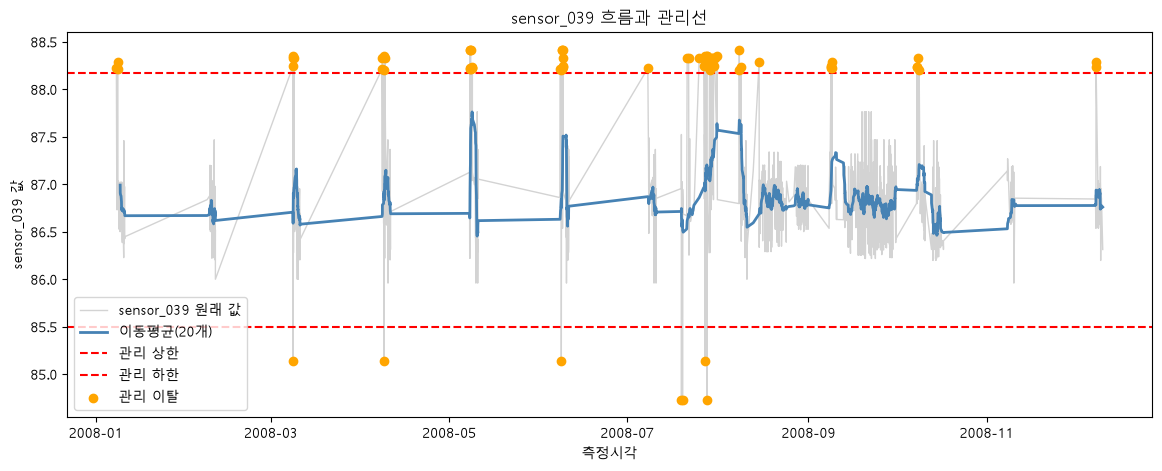

In [5]:
import matplotlib.pyplot as plt
import os

# 한글이 그림에서 깨지지 않도록 폰트를 지정한다 (Windows에 있는 맑은 고딕)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

os.makedirs("results", exist_ok=True)

# 관리선을 넘은 지점만 따로 골라낸다
이탈행 = df[df["이탈"]]

plt.figure(figsize=(14, 5))

# 원래 값은 옅게
plt.plot(df["측정시각"], df[센서], color="lightgray", linewidth=1, label=f"{센서} 원래 값")

# 이동평균은 진하게
plt.plot(df["측정시각"], df["이동평균"], color="steelblue", linewidth=2, label="이동평균(20개)")

# 관리 상한·하한을 가로선으로
plt.axhline(상한, color="red", linestyle="--", label="관리 상한")
plt.axhline(하한, color="red", linestyle="--", label="관리 하한")

# 선을 넘은 지점을 눈에 띄게 표시
plt.scatter(이탈행["측정시각"], 이탈행[센서], color="orange", zorder=3, label="관리 이탈")

plt.title(f"{센서} 흐름과 관리선")
plt.xlabel("측정시각")
plt.ylabel(f"{센서} 값")
plt.legend()

저장_경로 = os.path.join("results", "sensor_trend.png")
plt.savefig(저장_경로, dpi=150, bbox_inches="tight")
print("저장 위치:", os.path.abspath(저장_경로))

plt.show()

---
## Step 6: 조기 경보 리포트

In [6]:
# 근거 열 - df 안의 이상탐지·이탈 두 열만으로 만든다
df["근거"] = "없음"
df.loc[df["이상탐지"] & ~df["이탈"], "근거"] = "이상탐지"
df.loc[~df["이상탐지"] & df["이탈"], "근거"] = "관리선"
df.loc[df["이상탐지"] & df["이탈"], "근거"] = "둘 다"

# 둘 중 하나라도 걸린 행만 남겨 조기 경보 목록을 만든다
조기경보 = df[df["이상탐지"] | df["이탈"]].copy()

# 우선순위 - 둘 다가 맨 위, 그다음 나머지
우선순위표 = {"둘 다": 0, "이상탐지": 1, "관리선": 1}
조기경보["우선순위"] = 조기경보["근거"].map(우선순위표)
조기경보 = 조기경보.sort_values("우선순위", kind="stable").drop(columns="우선순위")

display(조기경보[["측정시각", "근거", "불량여부"]])

# 표에 쓸 네 숫자를 df 안의 열만으로 계산한다
둘다_건수 = int((df["근거"] == "둘 다").sum())
둘다_불량 = int(((df["근거"] == "둘 다") & (df["불량여부"] == 1)).sum())

하나라도_건수 = int((df["이상탐지"] | df["이탈"]).sum())
하나라도_불량 = int(((df["이상탐지"] | df["이탈"]) & (df["불량여부"] == 1)).sum())

전체불량건수 = int((df["불량여부"] == 1).sum())
못잡은불량 = 전체불량건수 - 하나라도_불량
전체불량률 = round(df["불량여부"].mean() * 100, 2)

요약표 = pd.DataFrame([
    {"항목": "둘 다 걸린 것", "건수": 둘다_건수, "그중 불량": 둘다_불량,
     "지목 중 진짜(%)": round(둘다_불량 / 둘다_건수 * 100, 1) if 둘다_건수 > 0 else 0.0},
    {"항목": "하나라도 걸린 것", "건수": 하나라도_건수, "그중 불량": 하나라도_불량,
     "지목 중 진짜(%)": round(하나라도_불량 / 하나라도_건수 * 100, 1) if 하나라도_건수 > 0 else 0.0},
    {"항목": "이 목록으로 못 잡은 불량", "건수": 못잡은불량, "그중 불량": "-", "지목 중 진짜(%)": "-"},
    {"항목": "전체 불량률(참고)", "건수": "-", "그중 불량": 전체불량건수, "지목 중 진짜(%)": 전체불량률},
]).set_index("항목")

요약표

,측정시각,근거,불량여부
5,2008-01-08 12:29:00,둘 다,0
149,2008-03-08 13:09:00,둘 다,0
201,2008-04-08 03:49:00,둘 다,0
210,2008-04-08 18:24:00,둘 다,0
213,2008-04-08 20:58:00,둘 다,1
...,...,...,...
1525,2008-11-10 07:39:00,이상탐지,0
1533,2008-12-08 04:23:00,이상탐지,0
1534,2008-12-08 06:16:00,이상탐지,0
1536,2008-12-08 11:29:00,관리선,0


,건수,그중 불량,지목 중 진짜(%)
항목,,,
둘 다 걸린 것,28,8,28.6
하나라도 걸린 것,122,19,15.6
이 목록으로 못 잡은 불량,85,-,-
전체 불량률(참고),-,104,6.64


## Step 6. 조기 경보 리포트

| 걸린 근거 | 건수 | 그중 불량 | 지목 중 진짜 |
|---|---|---|---|
| 둘 다 | [28] | [8] | [28.6%] |
| 둘 중 하나라도 | [122] | [19] | [15.6%] |
| (견줄 값) 전체 불량률 | 1567 | [104] | [6.64%] |

- 먼저 열어볼 것 : [둘 다 걸린 28건. 전체 불량률의 네 배 남짓이라 여기부터 본다]
- 무엇을 근거로 : [이상탐지 두 방법이 같이 짚었고, 관리선도 넘었다]
- 놓친 것 : [불량 104건 중 85건은 이 목록에 없다]
- 아직 못 미더운 점 : [관리선은 센서 하나만 봤다. 나머지 마흔아홉 개는 안 봤다]
- 다음에 해볼 것 : [센서를 더 골라 관리선을 긋고 겹치는지 본다]

---
## 직접 해보기 (도전) - 센서를 더 보면 달라지나

- 상황: 관리선을 센서 하나에만 그었다. 더 그으면 어떻게 될까
- 할 일: 센서를 여러 개 골라 관리선을 긋고, 몇 개나 넘었는지로 순위를 매긴다
- 결과물: 다섯 줄짜리 표 1개 + 한 줄 메모

## 1단 — 센서를 여러 개 보기

In [7]:
# 센서열 하나씩 자기 평균±3표준편차로 이탈 건수를 세어, 20~100건인 것만 후보로 남긴다
후보센서 = []
for s in 센서열:
    평균_s = df[s].mean()
    표준편차_s = df[s].std()
    이탈_s = (df[s] > 평균_s + 3 * 표준편차_s) | (df[s] < 평균_s - 3 * 표준편차_s)
    이탈건수_s = int(이탈_s.sum())
    if 20 <= 이탈건수_s <= 100:
        후보센서.append((s, 이탈건수_s))

선정센서 = [s for s, _ in 후보센서[:5]]

print("이탈 건수 20~100건인 후보:", len(후보센서), "개")
for s, n in 후보센서[:5]:
    print(f"  {s}: 이탈 {n}건")
print("선정한 다섯 센서:", 선정센서)

# 선정된 센서마다 자기 관리선을 넘었는지 표시하고, 줄마다 넘은 센서 개수를 센다
경보표시 = pd.DataFrame(index=df.index)
for s in 선정센서:
    평균_s = df[s].mean()
    표준편차_s = df[s].std()
    경보표시[s] = (df[s] > 평균_s + 3 * 표준편차_s) | (df[s] < 평균_s - 3 * 표준편차_s)

df["경보수"] = 경보표시.sum(axis=1)

print()
print(df["경보수"].value_counts().sort_index())

# 경보수를 0, 1, 2, 3 이상 네 구간으로 나눈다
def 구간나누기(n):
    return "3 이상" if n >= 3 else str(n)

df["경보수구간"] = df["경보수"].apply(구간나누기)

결과 = []
for 구간 in ["0", "1", "2", "3 이상"]:
    부분 = df[df["경보수구간"] == 구간]
    건수 = len(부분)
    그중불량 = int((부분["불량여부"] == 1).sum())
    결과.append({
        "경보수": 구간,
        "그런 줄이 몇 건": 건수,
        "그중 불량": 그중불량,
        "지목 중 진짜(%)": round(그중불량 / 건수 * 100, 1) if 건수 > 0 else 0.0,
    })

경보수표 = pd.DataFrame(결과).set_index("경보수")
경보수표

이탈 건수 20~100건인 후보: 18 개
  sensor_511: 이탈 32건
  sensor_349: 이탈 24건
  sensor_022: 이탈 24건
  sensor_437: 이탈 32건
  sensor_296: 이탈 54건
선정한 다섯 센서: ['sensor_511', 'sensor_349', 'sensor_022', 'sensor_437', 'sensor_296']

경보수
0    1463
1      69
2      11
3      21
4       3
Name: count, dtype: int64


,그런 줄이 몇 건,그중 불량,지목 중 진짜(%)
경보수,,,
0,1463,83,5.7
1,69,14,20.3
2,11,1,9.1
3 이상,24,6,25.0


### 몇 개의 센서에서 넘었나

| 넘은 센서 개수 | 그런 줄 | 그중 불량 | 지목 중 진짜 |
|---|---|---|---|
| 0개 | [1463] | [83] | [5.7%] |
| 1개 | [69] | [14] | [20.3%] |
| 2개 | [11] | [1] | [9.1%] |
| 3개 이상 | [24] | [6] | [25.0%] |

- 알게 된 것 : [하나도 안 걸린 줄은 5.7%로 전체와 비슷하고, 세 개 이상 걸린 줄은 25.0%로 약 다섯 배다. 2개 줄은 11건뿐이라 비율이 튀다]

## 2단 — 이동평균이 관리선을 넘는 순간

이동평균의 평균 86.84 / 표준편차 0.19
관리 상한(2표준편차) 87.22 / 관리 하한(2표준편차) 86.45

이동평균이 관리선을 넘은 구간: 5 개


,시작,끝,전체 건수,불량 건수,불량률(%)
0,2008-05-08 07:12:00,2008-05-10 04:48:00,21,2,9.52
1,2008-06-08 20:17:00,2008-06-10 04:26:00,15,2,13.33
2,2008-07-29 15:49:00,2008-07-29 15:49:00,1,1,100.00
3,2008-07-29 21:07:00,2008-08-09 04:21:00,27,5,18.52
4,2008-09-08 23:34:00,2008-09-13 00:25:00,13,2,15.38


저장 위치: c:\Users\subin\OneDrive\바탕 화면\secome-project\day05\lab15_timeseries\results\sensor_trend_zones.png


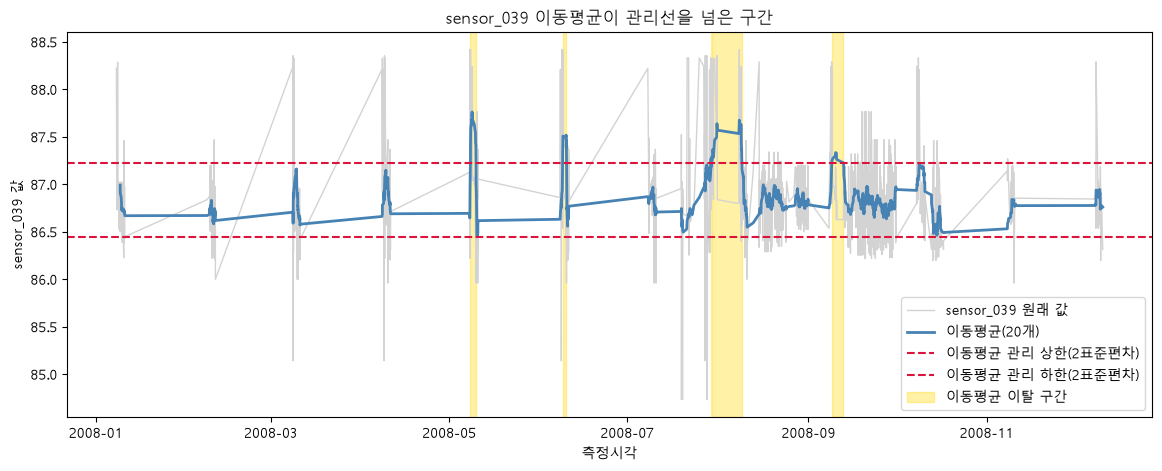

In [14]:
# 이동평균 자체의 평균·표준편차로 다시 선을 긋는다 (2 표준편차 기준)
이동평균평균 = df["이동평균"].mean()
이동평균표준편차 = df["이동평균"].std()

상한2 = 이동평균평균 + 2 * 이동평균표준편차
하한2 = 이동평균평균 - 2 * 이동평균표준편차

print(f"이동평균의 평균 {이동평균평균:.2f} / 표준편차 {이동평균표준편차:.2f}")
print(f"관리 상한(2표준편차) {상한2:.2f} / 관리 하한(2표준편차) {하한2:.2f}")

df["이동평균이탈"] = (df["이동평균"] > 상한2) | (df["이동평균"] < 하한2)

# 연속된 이탈 구간을 하나로 묶는다
그룹번호 = (df["이동평균이탈"] != df["이동평균이탈"].shift()).cumsum()

구간목록 = []
for 번호, 부분 in df.groupby(그룹번호):
    if not 부분["이동평균이탈"].iloc[0]:
        continue
    전체건수 = len(부분)
    불량건수 = int((부분["불량여부"] == 1).sum())
    구간목록.append({
        "시작": 부분["측정시각"].min(),
        "끝": 부분["측정시각"].max(),
        "전체 건수": 전체건수,
        "불량 건수": 불량건수,
        "불량률(%)": round(불량건수 / 전체건수 * 100, 2) if 전체건수 > 0 else 0.0,
    })

구간표 = pd.DataFrame(구간목록)

print()
print("이동평균이 관리선을 넘은 구간:", len(구간표), "개")
display(구간표)

plt.figure(figsize=(14, 5))

plt.plot(df["측정시각"], df[센서], color="lightgray", linewidth=1, label=f"{센서} 원래 값")
plt.plot(df["측정시각"], df["이동평균"], color="steelblue", linewidth=2, label="이동평균(20개)")

plt.axhline(상한2, color="crimson", linestyle="--", label="이동평균 관리 상한(2표준편차)")
plt.axhline(하한2, color="crimson", linestyle="--", label="이동평균 관리 하한(2표준편차)")

# 이동평균이 선을 넘은 구간을 색으로 칠한다
for i, row in 구간표.iterrows():
    plt.axvspan(row["시작"], row["끝"], color="gold", alpha=0.35,
                label="이동평균 이탈 구간" if i == 0 else None)

plt.title(f"{센서} 이동평균이 관리선을 넘은 구간")
plt.xlabel("측정시각")
plt.ylabel(f"{센서} 값")
plt.legend()

저장_경로2 = os.path.join("results", "sensor_trend_zones.png")
plt.savefig(저장_경로2, dpi=150, bbox_inches="tight")
print("저장 위치:", os.path.abspath(저장_경로2))

plt.show()

### 흐름이 선을 넘은 구간

| 구간 | 언제부터 언제까지 | 그 구간 건수 | 불량 | 불량률 |
|---|---|---|---|---|
| 1 | [5월 8일 ~ 5월 10일] | [21] | [2] | [9.52%] |
| 2 | [6월 8일 ~ 6월 10일] | [15] | [2] | [13.33%] |
| 3 | [7월 29일 한 줄] | [1] | [1] | [100.00%] |
| 4 | [7월 29일 ~ 8월 9일] | [27] | [5] | [18.52%] |
| 5 | [9월 8일 ~ 9월 13일] | [13] | [2] | [15.38%] |

- 알게 된 것 : [구간 안 77건의 불량률이 15.58%로 전체 6.64%의 두 배 넘는다. 4번 구간이 가장 길고 불량도 가장 많다]
- 이게 한 줄씩 보는 것과 다른 점 : [언제부터 언제까지인지 기간이 나온다. 그 날짜에 무슨 일이 있었는지 물어볼 수 있다]
- 못 믿을 줄 : [3번 구간은 1건짜리라 100%가 아무 뜻이 없다]